In [ ]:
# importing dependencies
import re
import nltk
from nltk.tokenize import word_tokenize
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from nltk.stem import WordNetLemmatizer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/Dataset

 admission_data.csv    Data		   News
 AmazonReview.csv      EmployeeData.csv    Salary_dataset.csv
 AnimalsData	       Fish.csv		  'Student Mental health.csv'
 Churn		       heart_failure.csv  'Student Mental health.gsheet'
 Churn_Modelling.csv  'IMDB Dataset.csv'  'Vegetable Images'


In [ ]:
# reading csv
data = pd.DataFrame()

for i in range(1,7):
    data = pd.concat([data,pd.read_csv("/content/drive/MyDrive/Dataset/News/inshort_news_data-"+str(i)+".csv")])


In [ ]:
# printing data
data.head()

,Unnamed: 0,news_headline,news_article,news_category
0,0,50-year-old problem of biology solved by Artif...,DeepMind's AI system 'AlphaFold' has been reco...,technology
1,1,Microsoft Teams to stop working on Internet Ex...,Microsoft Teams will stop working on Internet ...,technology
2,2,Hope US won't erect barriers to cooperation: C...,"China, in response to reports of US adding Chi...",technology
3,3,Global smartphone sales in Q3 falls 5.7% to 36...,The global smartphone sales in the third quart...,technology
4,4,EU hoping Biden will clarify US position on di...,The European Union (EU) is hoping that US Pres...,technology


In [ ]:
# shape
print("Shape : ",data.shape)

# dropping Unnamed:0 column
data.drop(columns=['Unnamed: 0'],axis=1,inplace=True)


Shape :  (10378, 4)


In [ ]:
# Columns
print("Column Names : ", data.columns.values)

# Unique Target columns
print(data['news_category'].unique())

Column Names :  ['news_headline' 'news_article' 'news_category']
['technology' 'sports' 'world' 'politics' 'entertainment' 'automobile'
 'science']


In [ ]:
# Value counts
print(data['news_category'].value_counts())

world            1818
entertainment    1787
sports           1650
technology       1547
politics         1346
science          1187
automobile       1043
Name: news_category, dtype: int64


In [ ]:
# Checking null values
print("\nNull Values : ")
print(data.isnull().sum())

# Checking duplicated values
print("\nDuplicated Values : ")
print(data.duplicated().sum())


Null Values : 
news_headline    0
news_article     0
news_category    0
dtype: int64

Duplicated Values : 
5724


In [ ]:
# Dealing with duplicated values
data = data.drop_duplicates()

# Checking duplicated values
print("\nDuplicated Values : ")
print(data.duplicated().sum())


Duplicated Values : 
0


In [ ]:
# Value counts
print(data['news_category'].value_counts())
print("\nIndex : ",data['news_category'].value_counts().index.tolist())
print("Values : ",data['news_category'].value_counts().values.tolist())

world            1033
entertainment    1022
sports            860
technology        814
politics          503
science           263
automobile        159
Name: news_category, dtype: int64

Index :  ['world', 'entertainment', 'sports', 'technology', 'politics', 'science', 'automobile']
Values :  [1033, 1022, 860, 814, 503, 263, 159]


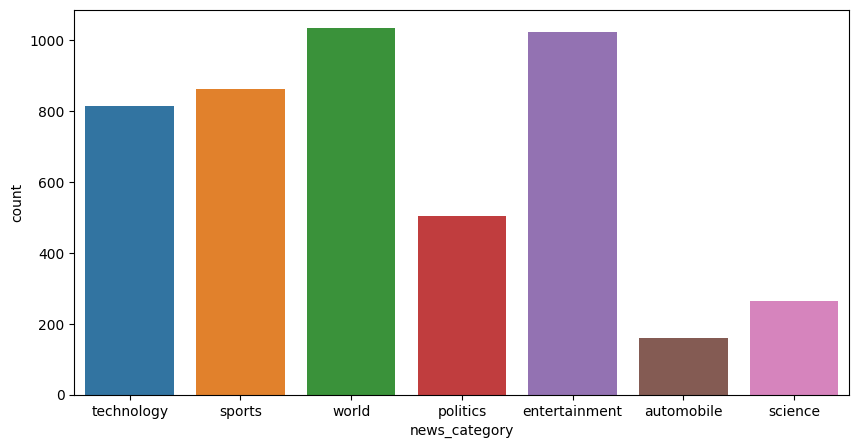

In [ ]:
# Count plot
plt.figure(figsize=(10,5))
sns.countplot(data=data,x='news_category')
plt.show()

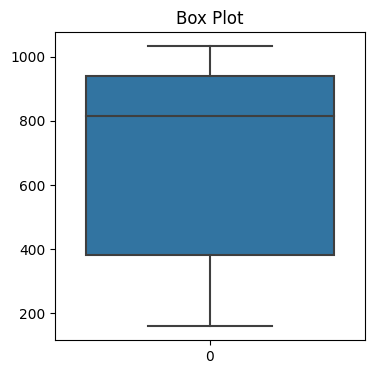

In [ ]:
# Box plot for the genre count
plt.figure(figsize=(4,4))
plt.title("Box Plot")
sns.boxplot(data=data['news_category'].value_counts().values.tolist())
plt.show()

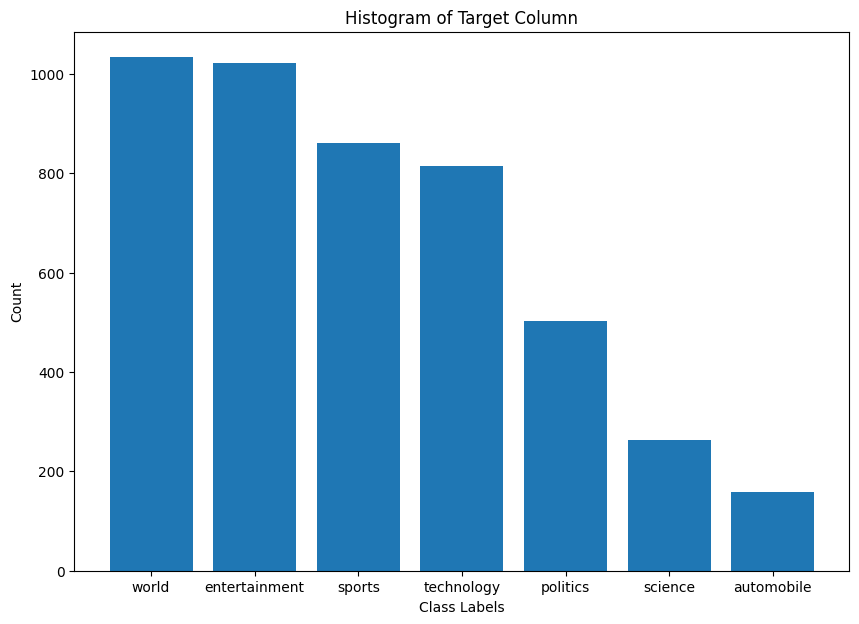

In [ ]:
# Histogram
plt.figure(figsize=(10,7))
labels = data['news_category'].value_counts().index.tolist()
counts = data['news_category'].value_counts().values.tolist()
plt.bar(labels, counts)
plt.xlabel('Class Labels')
plt.ylabel('Count')
plt.title('Histogram of Target Column')
plt.show()

In [ ]:
# Label Encoding target column
encoder_category = LabelEncoder()
data['news_category'] = encoder_category.fit_transform(data['news_category'])

In [ ]:
# target feature splitting
feature = data.iloc[:,:-1]
target = data.iloc[:,-1]

In [ ]:
# printing data
print("Feature:")
feature.head()

Feature:


,news_headline,news_article
0,50-year-old problem of biology solved by Artif...,DeepMind's AI system 'AlphaFold' has been reco...
1,Microsoft Teams to stop working on Internet Ex...,Microsoft Teams will stop working on Internet ...
2,Hope US won't erect barriers to cooperation: C...,"China, in response to reports of US adding Chi..."
3,Global smartphone sales in Q3 falls 5.7% to 36...,The global smartphone sales in the third quart...
4,EU hoping Biden will clarify US position on di...,The European Union (EU) is hoping that US Pres...


In [ ]:
# printing data
print("Feature:")
target.head()

Feature:


0    5
1    5
2    5
3    5
4    5
Name: news_category, dtype: int64

In [ ]:
# nltk
# Downloading stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
# Stopwords List
stopwords_list = stopwords.words("english")
print("\nStop-words : ")
print(stopwords_list)
print("Total Stop Words in corpus : ",len(stopwords_list))


Stop-words : 
['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# For Lemmatizing
word_lama = WordNetLemmatizer()

def text_cleaning(text):
    # Remove the dot from floating-point numbers and replace non-alphanumeric characters with a space
    cleaned_text = re.sub(r"\b(\d+)\.\d+\b",r'\1', text)
    cleaned_text = re.sub(r"[^a-zA-Z0-9]", " ", cleaned_text.lower())
    # creating tokens
    cleaned_text = word_tokenize(cleaned_text,language="english")
    # lemmatizing text
    lemmatizing_data = [word_lama.lemmatize(word) for word in cleaned_text]
    # stop words removal
    cleaned_text = [' '.join([word for word in lemmatizing_data if not word in stopwords_list])]
    return cleaned_text[0]


In [ ]:
# special symbols removal
feature['news_headline'] = feature['news_headline'].apply(lambda headline: text_cleaning(headline))
feature['news_article'] = feature['news_article'].apply(lambda headline: text_cleaning(headline))

In [ ]:
feature.head()

,news_headline,news_article
0,50 year old problem biology solved artificial ...,deepmind ai system alphafold ha recognised sol...
1,microsoft team stop working internet explorer ...,microsoft team stop working internet explorer ...
2,hope u erect barrier cooperation china blackli...,china response report u adding chinese chipmak...
3,global smartphone sale q3 fall 5 36 cr unit ga...,global smartphone sale third quarter 2020 fell...
4,eu hoping biden clarify u position digital tax...,european union eu hoping u president elect joe...


In [ ]:
# train test split
x_train,x_test,y_train,y_test = train_test_split(feature,target,test_size=0.20)

In [ ]:
# Applying Count Vectorize
# (Bag of Words)
vectorizer = CountVectorizer()

# Preprocess the text columns using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('headline', vectorizer, 'news_headline'),
        ('article', vectorizer, 'news_article')
    ])

In [ ]:
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [ ]:
smote_sampling = SMOTE()
x_train, y_train = smote_sampling.fit_resample(x_train,y_train)

In [ ]:
naive = MultinomialNB()
naive.fit(x_train,y_train)
y_predicted = naive.predict(x_test)

# Accuracy Sore
print("\nAccuracy : ",accuracy_score(y_true=y_test,y_pred=y_predicted)*100)
print("\nConfusion Martix : \n ")
print(confusion_matrix(y_true=y_test,y_pred=y_predicted))
print("\nClassification Report : \n ")
print(classification_report(y_true=y_test,y_pred=y_predicted))


Accuracy :  88.7218045112782

Confusion Martix : 
 
[[ 23   0   0   1   0   7   0]
 [  1 184   5   0   3   0   2]
 [  0   0  96   0   1   0   5]
 [  0   0   1  38   0   4   5]
 [  1   2   0   0 172   0   6]
 [  6   1   2   4   1 136  17]
 [  0   2   4   2   2  20 177]]

Classification Report : 
 
              precision    recall  f1-score   support

           0       0.74      0.74      0.74        31
           1       0.97      0.94      0.96       195
           2       0.89      0.94      0.91       102
           3       0.84      0.79      0.82        48
           4       0.96      0.95      0.96       181
           5       0.81      0.81      0.81       167
           6       0.83      0.86      0.84       207

    accuracy                           0.89       931
   macro avg       0.87      0.86      0.86       931
weighted avg       0.89      0.89      0.89       931



In [ ]:
svc = SVC()
svc.fit(x_train,y_train)
y_predicted = svc.predict(x_test)

# Accuracy Sore
print("\nAccuracy : ",accuracy_score(y_true=y_test,y_pred=y_predicted)*100)
print("\nConfusion Martix : \n ")
print(confusion_matrix(y_true=y_test,y_pred=y_predicted))
print("\nClassification Report : \n ")
print(classification_report(y_true=y_test,y_pred=y_predicted))


Accuracy :  82.49194414607949

Confusion Martix : 
 
[[ 10   0   0   1   0  14   6]
 [  1 181   1   0   5   4   3]
 [  0   1  86   0   1   2  12]
 [  0   2   0  26   0  11   9]
 [  0   3   0   0 169   1   8]
 [  6   0   3   4   0 126  28]
 [  1   1   5   1   6  23 170]]

Classification Report : 
 
              precision    recall  f1-score   support

           0       0.56      0.32      0.41        31
           1       0.96      0.93      0.95       195
           2       0.91      0.84      0.87       102
           3       0.81      0.54      0.65        48
           4       0.93      0.93      0.93       181
           5       0.70      0.75      0.72       167
           6       0.72      0.82      0.77       207

    accuracy                           0.82       931
   macro avg       0.80      0.74      0.76       931
weighted avg       0.83      0.82      0.82       931



In [ ]:
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)
y_predicted = knn.predict(x_test)

# Accuracy Sore
print("\nAccuracy : ",accuracy_score(y_true=y_test,y_pred=y_predicted)*100)
print("\nConfusion Martix : \n ")
print(confusion_matrix(y_true=y_test,y_pred=y_predicted))
print("\nClassification Report : \n ")
print(classification_report(y_true=y_test,y_pred=y_predicted))


Accuracy :  36.09022556390977

Confusion Martix : 
 
[[ 26   0   0   2   0   3   0]
 [ 32   1  15  73  22  52   0]
 [  1   0  82   6   2  11   0]
 [  1   0   2  41   0   4   0]
 [  7   0  11  20 125  18   0]
 [ 61   0  11  29   5  61   0]
 [ 32   0  36  67  11  61   0]]

Classification Report : 
 
              precision    recall  f1-score   support

           0       0.16      0.84      0.27        31
           1       1.00      0.01      0.01       195
           2       0.52      0.80      0.63       102
           3       0.17      0.85      0.29        48
           4       0.76      0.69      0.72       181
           5       0.29      0.37      0.32       167
           6       0.00      0.00      0.00       207

    accuracy                           0.36       931
   macro avg       0.42      0.51      0.32       931
weighted avg       0.48      0.36      0.29       931



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)
y_predicted = dtc.predict(x_test)

# Accuracy Sore
print("\nAccuracy : ",accuracy_score(y_true=y_test,y_pred=y_predicted)*100)
print("\nConfusion Martix : \n ")
print(confusion_matrix(y_true=y_test,y_pred=y_predicted))
print("\nClassification Report : \n ")
print(classification_report(y_true=y_test,y_pred=y_predicted))


Accuracy :  70.56928034371643

Confusion Martix : 
 
[[ 13   0   0   1   2  14   1]
 [  2 168   3   4   5   6   7]
 [  0   2  92   1   1   3   3]
 [  0   0   4  24   1   8  11]
 [  1   8   3   1 157   4   7]
 [ 15   7  11  11   1  94  28]
 [  5   7  23   8  13  42 109]]

Classification Report : 
 
              precision    recall  f1-score   support

           0       0.36      0.42      0.39        31
           1       0.88      0.86      0.87       195
           2       0.68      0.90      0.77       102
           3       0.48      0.50      0.49        48
           4       0.87      0.87      0.87       181
           5       0.55      0.56      0.56       167
           6       0.66      0.53      0.58       207

    accuracy                           0.71       931
   macro avg       0.64      0.66      0.65       931
weighted avg       0.71      0.71      0.70       931



In [ ]:
rfc = RandomForestClassifier()
rfc.fit(x_train,y_train)
y_predicted = rfc.predict(x_test)

# Accuracy Sore
print("\nAccuracy : ",accuracy_score(y_true=y_test,y_pred=y_predicted)*100)
print("\nConfusion Martix : \n ")
print(confusion_matrix(y_true=y_test,y_pred=y_predicted))
print("\nClassification Report : \n ")
print(classification_report(y_true=y_test,y_pred=y_predicted))


Accuracy :  76.90655209452201

Confusion Martix : 
 
[[ 21   0   0   1   0   9   0]
 [  1 178   7   0   3   4   2]
 [  0   1  99   0   1   0   1]
 [  1   1   1  35   0   8   2]
 [  2   4   2   1 169   0   3]
 [ 20   1   6  13   1 106  20]
 [  6   3  36  15  12  27 108]]

Classification Report : 
 
              precision    recall  f1-score   support

           0       0.41      0.68      0.51        31
           1       0.95      0.91      0.93       195
           2       0.66      0.97      0.78       102
           3       0.54      0.73      0.62        48
           4       0.91      0.93      0.92       181
           5       0.69      0.63      0.66       167
           6       0.79      0.52      0.63       207

    accuracy                           0.77       931
   macro avg       0.71      0.77      0.72       931
weighted avg       0.79      0.77      0.77       931



In [ ]:
# GradientBoostingClassifier
gbc = GradientBoostingClassifier()
gbc.fit(x_train,y_train)
y_predicted = gbc.predict(x_test)

# Accuracy Sore
print("\nAccuracy : ",accuracy_score(y_true=y_test,y_pred=y_predicted)*100)
print("\nConfusion Martix : \n ")
print(confusion_matrix(y_true=y_test,y_pred=y_predicted))
print("\nClassification Report : \n ")
print(classification_report(y_true=y_test,y_pred=y_predicted))


Accuracy :  83.88829215896885

Confusion Martix : 
 
[[ 25   0   0   1   0   5   0]
 [  1 174   3   0   4   5   8]
 [  0   1  92   1   1   2   5]
 [  0   0   1  36   0   7   4]
 [  2   4   2   2 166   0   5]
 [ 12   1   3   9   0 125  17]
 [  2   2  10   9   5  16 163]]

Classification Report : 
 
              precision    recall  f1-score   support

           0       0.60      0.81      0.68        31
           1       0.96      0.89      0.92       195
           2       0.83      0.90      0.86       102
           3       0.62      0.75      0.68        48
           4       0.94      0.92      0.93       181
           5       0.78      0.75      0.76       167
           6       0.81      0.79      0.80       207

    accuracy                           0.84       931
   macro avg       0.79      0.83      0.81       931
weighted avg       0.85      0.84      0.84       931

